In [1]:
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


In [27]:
adata = sc.read_10x_h5(f'SC5pv2_GEX_Human_Lung_Carcinoma_DTC_filtered_feature_bc_matrix.h5')

/Users/colinpascual/Desktop/uzunlab/clean_analysis/single_cell/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/Users/colinpascual/Desktop/uzunlab/clean_analysis/single_cell/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [28]:
adata

AnnData object with n_obs × n_vars = 2616 × 36601
    var: 'gene_ids', 'feature_types', 'genome'

In [4]:
#DOUBLET REMOVAL

sc.pp.filter_genes(adata, min_cells=10)
sc.pp.highly_variable_genes(adata, n_top_genes = 2000, subset = True, flavor = 'seurat_v3')


/Users/colinpascual/Desktop/uzunlab/clean_analysis/single_cell/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/Users/colinpascual/Desktop/uzunlab/clean_analysis/single_cell/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


In [5]:
import scvi
print(scvi.__version__)
print(dir(scvi))
scvi.model.SCVI.setup_anndata(adata)
vae = scvi.model.SCVI(adata)
vae.train()

/Users/colinpascual/Desktop/uzunlab/clean_analysis/single_cell/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/colinpascual/Desktop/uzunlab/clean_analysis/single_cell/lib/python3.10/site-packages/scvi/model/_scvi.py:168: UserWarning: This dataset has some empty cells, this might fail inference.Data should be filtered with `scanpy.pp.filter_cells()`
  library_log_means, library_log_vars = _init_library_size(
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/colinpascual/Desktop/uzunlab/clean_analysis/single_cell/lib/python3.10/site-packages/lightning/pytorch/trainer/setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
/Users/colinpascual/Desktop/uzunlab/clean_analysis/single_cell/lib

1.2.0
['REGISTRY_KEYS', '__all__', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', '__version__', '_constants', '_settings', '_types', 'data', 'dataloaders', 'distributions', 'external', 'logging', 'model', 'module', 'nn', 'package_name', 'scvi_logger', 'settings', 'train', 'utils', 'version', 'warnings']
Epoch 400/400: 100%|██████████| 400/400 [10:42<00:00,  1.02it/s, v_num=1, train_loss_step=428, train_loss_epoch=398]

`Trainer.fit` stopped: `max_epochs=400` reached.


Epoch 400/400: 100%|██████████| 400/400 [10:42<00:00,  1.61s/it, v_num=1, train_loss_step=428, train_loss_epoch=398]


In [6]:
solo = scvi.external.SOLO.from_scvi_model(vae)
solo.train()

INFO     Creating doublets, preparing SOLO model.                                                                  


/Users/colinpascual/Desktop/uzunlab/clean_analysis/single_cell/lib/python3.10/site-packages/scvi/external/solo/_model.py:220: RuntimeWarning: divide by zero encountered in log
  latent_adata = AnnData(np.concatenate([latent_rep, np.log(lib_size)], axis=1))
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/colinpascual/Desktop/uzunlab/clean_analysis/single_cell/lib/python3.10/site-packages/lightning/pytorch/trainer/setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
/Users/colinpascual/Desktop/uzunlab/clean_analysis/single_cell/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:424: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.
/Users/colinpascual/Desktop/uzunlab/clean_analysis/single_ce

Epoch 1/400:   0%|          | 1/400 [00:00<02:13,  3.00it/s, v_num=1, train_loss_step=nan, train_loss_epoch=nan]
Monitored metric validation_loss = nan is not finite. Previous best value was inf. Signaling Trainer to stop.


In [7]:
df = solo.predict()
df['prediction'] = solo.predict(soft = False)

df.index = df.index.map(lambda x: x[:-2])

df.groupby('prediction').count()

/Users/colinpascual/Desktop/uzunlab/clean_analysis/single_cell/lib/python3.10/site-packages/torch/utils/_contextlib.py:116: UserWarning: Prior to scvi-tools 1.1.3, `SOLO.predict` with `soft=True` (the default option) returned logits instead of probabilities. This behavior has since been corrected to return probabiltiies. The previous behavior can be replicated by passing in `return_logits=True`.
  return func(*args, **kwargs)
/Users/colinpascual/Desktop/uzunlab/clean_analysis/single_cell/lib/python3.10/site-packages/torch/utils/_contextlib.py:116: UserWarning: Prior to scvi-tools 1.1.3, `SOLO.predict` with `soft=True` (the default option) returned logits instead of probabilities. This behavior has since been corrected to return probabiltiies. The previous behavior can be replicated by passing in `return_logits=True`.
  return func(*args, **kwargs)
/Users/colinpascual/Desktop/uzunlab/clean_analysis/single_cell/lib/python3.10/site-packages/scvi/external/solo/_model.py:447: FutureWarning:

,doublet,singlet
prediction,,


In [ ]:
df['dif'] = df.doublet - df.singlet
df

In [ ]:
doublets = df[(df.prediction == 'doublet') & (df.dif > 1)]
doublets

In [ ]:
adata = sc.read_10x_h5(f'SC5pv2_GEX_Human_Lung_Carcinoma_DTC_filtered_feature_bc_matrix.h5')
adata.obs['doublet'] = adata.obs.index.isin(doublets.index)
adata.obs

In [ ]:
adata = adata[~adata.obs.doublet]
adata

In [29]:
#Preprocessing
adata.var['mt'] = adata.var.index.str.startswith('MT-') #label mitochrondrial genes



In [30]:
import pandas as pd
ribo_url = "http://software.broadinstitute.org/gsea/msigdb/download_geneset.jsp?geneSetName=KEGG_RIBOSOME&fileType=txt"
ribo_genes = pd.read_table(ribo_url, skiprows=2, header = None)
ribo_genes

,0
0,FAU
1,MRPL13
2,RPL10
3,RPL10A
4,RPL10L
...,...
83,RPS9
84,RPSA
85,RSL24D1
86,RSL24D1P11


In [31]:
adata.var['ribo'] = adata.var_names.isin(ribo_genes[0].values)
adata.obs

""
AAACCTGGTGGCAAAC-1
AAACCTGTCGCATGGC-1
AAACCTGTCGTACCGG-1
AAACGGGCACTAAGTC-1
AAACGGGCACTAGTAC-1
...
TTTGTCACATTGGTAC-1
TTTGTCAGTACTTAGC-1
TTTGTCAGTTACTGAC-1
TTTGTCATCACCGGGT-1


In [32]:
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt', 'ribo'], percent_top=None, log1p=False, inplace=True)

In [34]:
sc.pp.filter_genes(adata, min_cells=3)


/Users/colinpascual/Desktop/uzunlab/clean_analysis/single_cell/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [35]:
adata

AnnData object with n_obs × n_vars = 2616 × 21551
    obs: 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'

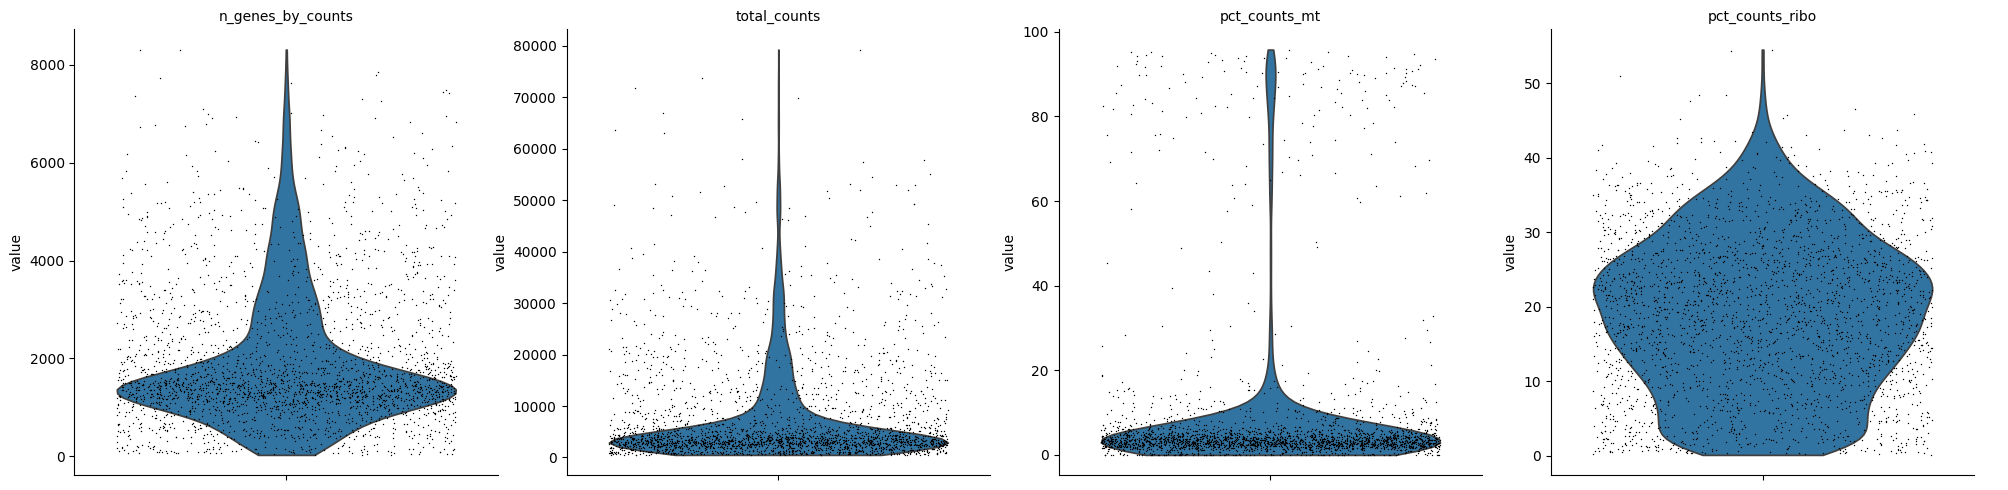

In [36]:
#sc.filter_cells(adata, min_counts = 200)
adata.var_names_make_unique()
sc.pl.violin(adata, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt', 'pct_counts_ribo'], 
             jitter=0.4, multi_panel=True)

In [41]:
adata

View of AnnData object with n_obs × n_vars = 2563 × 21551
    obs: 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'

In [38]:
import numpy as np

In [39]:
upper_lim = np.quantile(adata.obs.n_genes_by_counts.values, .98)
upper_lim

5873.3999999999905

In [40]:
adata = adata[adata.obs.n_genes_by_counts < upper_lim]


In [45]:
adata.obs.sort_values('pct_counts_mt', ascending = False)

,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,total_counts_ribo,pct_counts_ribo
GGCAATTGTTACAGAA-1,34,904.0,866.0,95.796463,6.0,0.663717
ACTTTCATCATATCGG-1,67,1601.0,1526.0,95.315430,14.0,0.874453
CCTTTCTGTCCGAACC-1,44,1109.0,1056.0,95.220917,12.0,1.082056
TATCAGGTCTTGAGGT-1,35,1070.0,1018.0,95.140190,4.0,0.373832
GCGCAACAGATGCCTT-1,30,792.0,752.0,94.949493,4.0,0.505050
...,...,...,...,...,...,...
TATCTCAAGCTAACAA-1,411,673.0,0.0,0.000000,168.0,24.962852
GTGCTTCAGGGCTTGA-1,749,1205.0,0.0,0.000000,142.0,11.784232
ACGCCAGTCGCCTGTT-1,1759,7202.0,0.0,0.000000,3430.0,47.625660
TACAGTGAGTCGAGTG-1,366,677.0,0.0,0.000000,22.0,3.249631


In [53]:
adata = adata[adata.obs.pct_counts_mt < 20]
adata = adata[adata.obs.pct_counts_ribo < 40]

In [54]:
adata

View of AnnData object with n_obs × n_vars = 2346 × 21551
    obs: 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'

In [55]:
#Normalization
adata.X.sum(axis=1)

matrix([[ 2525.],
        [ 3122.],
        [36369.],
        ...,
        [ 5838.],
        [ 4267.],
        [ 4136.]], dtype=float32)

In [56]:
sc.pp.normalize_total(adata, target_sum=1e4)

/Users/colinpascual/Desktop/uzunlab/clean_analysis/single_cell/lib/python3.10/site-packages/scanpy/preprocessing/_normalization.py:207: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


In [57]:
sc.pp.log1p(adata)

In [58]:
adata.raw = adata

In [59]:
#Clustering
adata

AnnData object with n_obs × n_vars = 2346 × 21551
    obs: 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
    uns: 'log1p'

In [60]:
sc.pp.highly_variable_genes(adata, n_top_genes = 2000)

In [61]:
adata.var

,gene_ids,feature_types,genome,mt,ribo,n_cells_by_counts,mean_counts,pct_dropout_by_counts,total_counts,n_cells,highly_variable,means,dispersions,dispersions_norm
LINC01409,ENSG00000237491,Gene Expression,GRCh38,False,False,99,0.040520,96.215596,106.0,99,False,0.070540,1.249045,0.135039
LINC01128,ENSG00000228794,Gene Expression,GRCh38,False,False,193,0.085627,92.622324,224.0,193,False,0.132304,1.161612,0.014030
LINC00115,ENSG00000225880,Gene Expression,GRCh38,False,False,45,0.017966,98.279817,47.0,45,False,0.034194,1.762040,0.845037
FAM41C,ENSG00000230368,Gene Expression,GRCh38,False,False,9,0.003440,99.655963,9.0,9,False,0.003961,0.696238,-0.630060
SAMD11,ENSG00000187634,Gene Expression,GRCh38,False,False,6,0.003058,99.770642,8.0,6,False,0.001981,0.360361,-1.094921
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
AC240274.1,ENSG00000271254,Gene Expression,GRCh38,False,False,15,0.005734,99.426606,15.0,15,False,0.004942,0.083237,-1.478468
AC233755.2,ENSG00000277856,Gene Expression,GRCh38,False,False,12,1.853976,99.541284,4850.0,12,True,0.823405,7.025279,5.855906
AC233755.1,ENSG00000275063,Gene Expression,GRCh38,False,False,6,0.069572,99.770642,182.0,6,True,0.034198,3.963286,3.891615
AC007325.4,ENSG00000278817,Gene Expression,GRCh38,False,False,7,0.002676,99.732416,7.0,7,False,0.002749,0.721941,-0.594486


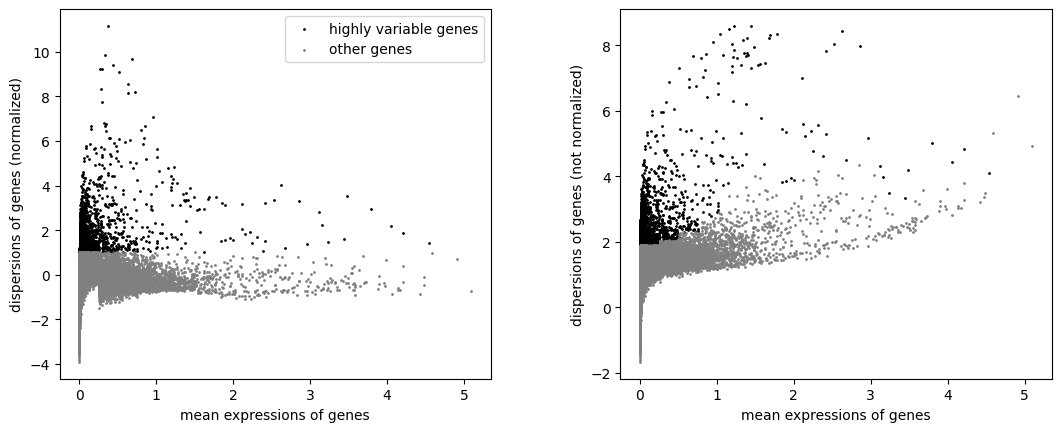

In [62]:
sc.pl.highly_variable_genes(adata)

In [63]:
adata = adata[:, adata.var.highly_variable]

In [64]:
sc.pp.regress_out(adata, ['total_counts', 'pct_counts_mt', 'pct_counts_ribo'])


/Users/colinpascual/Desktop/uzunlab/clean_analysis/single_cell/lib/python3.10/site-packages/scanpy/preprocessing/_simple.py:668: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


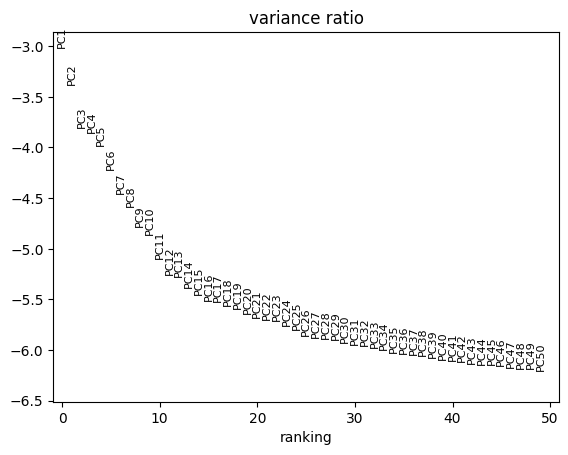

In [65]:
sc.pp.scale(adata, max_value=10)
sc.tl.pca(adata, svd_solver='arpack')
sc.pl.pca_variance_ratio(adata, log=True, n_pcs = 50)

In [66]:
sc.pp.neighbors(adata, n_pcs = 30)

In [67]:
sc.tl.umap(adata)

In [75]:
sc.tl.leiden(adata, resolution=0.5)

/var/folders/w6/clw62qpj5t96m16fx8w7k0th0000gn/T/ipykernel_94855/1771924308.py:1: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, resolution=0.5)


In [76]:
adata.obs

,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,total_counts_ribo,pct_counts_ribo,leiden
AAACCTGGTGGCAAAC-1,1341,2526.0,74.0,2.929533,511.0,20.229612,0
AAACCTGTCGCATGGC-1,1190,3122.0,113.0,3.619475,824.0,26.393339,2
AAACCTGTCGTACCGG-1,4857,36370.0,934.0,2.568051,2405.0,6.612593,1
AAACGGGCACTAAGTC-1,2648,7899.0,222.0,2.810482,2072.0,26.231171,0
AAACGGGCACTAGTAC-1,4035,16721.0,534.0,3.193589,2376.0,14.209676,1
...,...,...,...,...,...,...,...
TTTGTCACAGGCGATA-1,599,958.0,47.0,4.906054,212.0,22.129436,0
TTTGTCACATCACGTA-1,736,1696.0,1.0,0.058962,631.0,37.205189,4
TTTGTCAGTACTTAGC-1,1451,5838.0,881.0,15.090784,686.0,11.750600,1
TTTGTCATCACCGGGT-1,1756,4269.0,200.0,4.684938,1047.0,24.525650,3


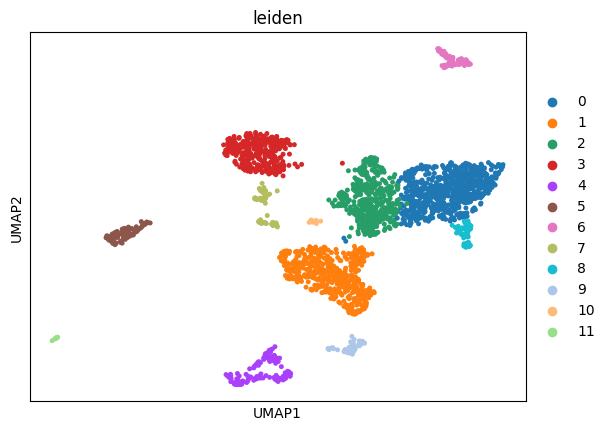

In [77]:
sc.pl.umap(adata, color=['leiden'])


In [78]:
sc.tl.rank_genes_groups(adata, 'leiden')


In [79]:
markers = sc.get.rank_genes_groups_df(adata, None)
markers = markers[(markers.pvals_adj < 0.05) & (markers.logfoldchanges > .5)]
markers

,group,names,scores,logfoldchanges,pvals,pvals_adj
0,0,CCL5,48.850052,5.645436,1.031218e-254,2.222378e-250
1,0,CD8A,32.292278,5.470825,9.052947e-141,3.902001e-137
2,0,FYN,26.354975,2.640475,1.029546e-118,1.232652e-115
3,0,CD3E,26.165695,2.896184,6.927477e-115,7.464703e-112
4,0,CD7,25.845627,3.002997,5.376801e-114,5.267065e-111
...,...,...,...,...,...,...
237204,11,TYROBP,2.784924,1.374934,2.301904e-02,4.357341e-02
237207,11,EHMT1,2.754699,2.216612,2.476366e-02,4.663011e-02
237208,11,COX17,2.728252,1.657297,2.571841e-02,4.824244e-02
237209,11,LSM5,2.723542,2.031888,2.595818e-02,4.865408e-02


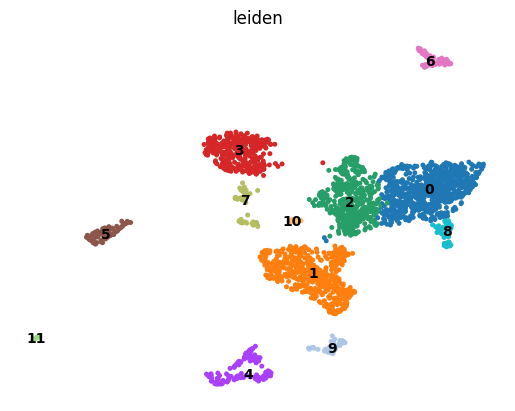

In [80]:
sc.pl.umap(adata, color = ['leiden'], frameon = False, legend_loc = "on data")


In [85]:
print("{")
for x in range(11):
    print(f'"{x}": " ",')
print("}")

{
"0": " ",
"1": " ",
"2": " ",
"3": " ",
"4": " ",
"5": " ",
"6": " ",
"7": " ",
"8": " ",
"9": " ",
"10": " ",
}


In [86]:
labels = {
"0": "CD8+ T cells",
"1": " ",
"2": "CD4+ T cells",
"3": " ",
"4": " ",
"5": " ",
"6": " ",
"7": " ",
"8": " ",
"9": " ",
"10": " ",
}

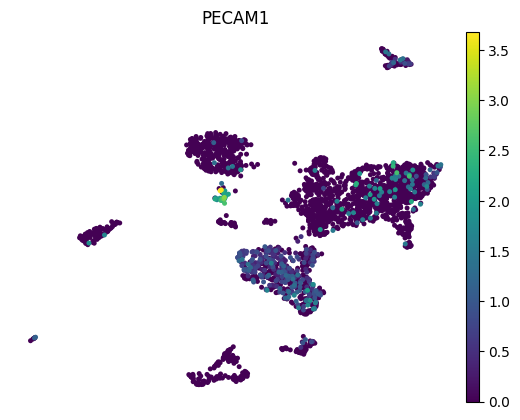

In [93]:
sc.pl.umap(adata, color=['PECAM1'], frameon=False)

In [94]:
markers[markers.names == 'PECAM1']

,group,names,scores,logfoldchanges,pvals,pvals_adj
22310,1,PECAM1,11.875400,2.043952,7.709448e-30,1.594494e-28
151028,7,PECAM1,5.340528,3.476594,1.727272e-06,1.771749e-05
